<a href="https://colab.research.google.com/github/tandragnaneswar-sys/ViT-Robustness-Evaluation/blob/main/deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
print("GPU Available:", torch.cuda.is_available())

GPU Available: True


In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tandragnaneswar","key":"b87ae6d5d5be766d76577e0010555692"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d vbookshelf/v2-plant-seedlings-dataset

Dataset URL: https://www.kaggle.com/datasets/vbookshelf/v2-plant-seedlings-dataset
License(s): CC-BY-SA-4.0
100% 3.19G/3.19G [00:31<00:00, 107MB/s]



In [5]:
!unzip v2-plant-seedlings-dataset.zip -d dataset

Streaming output truncated to the last 5000 lines.
  inflating: dataset/nonsegmentedv2/Charlock/308.png  
  inflating: dataset/nonsegmentedv2/Charlock/309.png  
  inflating: dataset/nonsegmentedv2/Charlock/31.png  
  inflating: dataset/nonsegmentedv2/Charlock/310.png  
  inflating: dataset/nonsegmentedv2/Charlock/311.png  
  inflating: dataset/nonsegmentedv2/Charlock/312.png  
  inflating: dataset/nonsegmentedv2/Charlock/313.png  
  inflating: dataset/nonsegmentedv2/Charlock/314.png  
  inflating: dataset/nonsegmentedv2/Charlock/315.png  
  inflating: dataset/nonsegmentedv2/Charlock/316.png  
  inflating: dataset/nonsegmentedv2/Charlock/317.png  
  inflating: dataset/nonsegmentedv2/Charlock/318.png  
  inflating: dataset/nonsegmentedv2/Charlock/319.png  
  inflating: dataset/nonsegmentedv2/Charlock/32.png  
  inflating: dataset/nonsegmentedv2/Charlock/320.png  
  inflating: dataset/nonsegmentedv2/Charlock/321.png  
  inflating: dataset/nonsegmentedv2/Charlock/322.png  
  inflating: dat

In [6]:
crop_classes = ['Maize', 'Common wheat', 'Sugar beet']

In [7]:
import os

base_dir = "processed_dataset"
os.makedirs(os.path.join(base_dir, "crop"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "weed"), exist_ok=True)

In [10]:
import shutil
import os

train_path = "dataset"

for class_name in os.listdir(train_path):

    # Skip unwanted folder
    if class_name == "nonsegmentedv2":
        continue

    class_path = os.path.join(train_path, class_name)

    if class_name in crop_classes:
        target_folder = os.path.join(base_dir, "crop")
    else:
        target_folder = os.path.join(base_dir, "weed")

    for img in os.listdir(class_path):
        src = os.path.join(class_path, img)

        # avoid filename conflicts
        dst = os.path.join(target_folder, class_name + "_" + img)

        shutil.copy(src, dst)

print("Dataset conversion done!")

Dataset conversion done!


In [11]:
print("Crop images:", len(os.listdir("processed_dataset/crop")))
print("Weed images:", len(os.listdir("processed_dataset/weed")))

Crop images: 973
Weed images: 4566


In [12]:
import os
import shutil
import random

base_dir = "processed_dataset"

split_dir = "final_dataset"

for split in ["train", "val", "test"]:
    for cls in ["crop", "weed"]:
        os.makedirs(os.path.join(split_dir, split, cls), exist_ok=True)

def split_data(class_name, split_ratio=(0.7, 0.15, 0.15)):
    path = os.path.join(base_dir, class_name)
    images = os.listdir(path)
    random.shuffle(images)

    total = len(images)
    train_end = int(split_ratio[0] * total)
    val_end = int((split_ratio[0] + split_ratio[1]) * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    for img in train_imgs:
        shutil.copy(os.path.join(path, img),
                    os.path.join(split_dir, "train", class_name, img))

    for img in val_imgs:
        shutil.copy(os.path.join(path, img),
                    os.path.join(split_dir, "val", class_name, img))

    for img in test_imgs:
        shutil.copy(os.path.join(path, img),
                    os.path.join(split_dir, "test", class_name, img))

# Apply split
split_data("crop")
split_data("weed")

print("Dataset split done!")

Dataset split done!


In [13]:
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    for cls in ["crop", "weed"]:
        path = f"final_dataset/{split}/{cls}"
        print(cls, ":", len(os.listdir(path)))


TRAIN
crop : 681
weed : 3196

VAL
crop : 146
weed : 685

TEST
crop : 146
weed : 685


In [14]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [15]:
from torchvision import datasets

train_data = datasets.ImageFolder("final_dataset/train", transform=train_transform)
val_data = datasets.ImageFolder("final_dataset/val", transform=val_test_transform)
test_data = datasets.ImageFolder("final_dataset/test", transform=val_test_transform)

In [16]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [17]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels[:10])

torch.Size([32, 3, 224, 224])
tensor([0, 1, 1, 1, 0, 1, 0, 0, 1, 1])


In [18]:
import torchvision.models as models

model = models.vit_b_16(pretrained=True)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 162MB/s]


In [19]:
import torch.nn as nn

model.heads = nn.Linear(model.heads.head.in_features, 2)

In [21]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [22]:
import torch.nn as nn
import torch

# class counts
crop_count = 973
weed_count = 4566

total = crop_count + weed_count

weight_crop = total / crop_count
weight_weed = total / weed_count

class_weights = torch.tensor([weight_crop, weight_weed], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [23]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [24]:
import torch

num_epochs = 5  # you can increase later

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss:.4f}")

Epoch [1/5], Loss: 48.6464
Epoch [2/5], Loss: 14.3989
Epoch [3/5], Loss: 10.2664
Epoch [4/5], Loss: 9.7987
Epoch [5/5], Loss: 8.0892


In [25]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Validation Accuracy: {accuracy:.2f}%")


Validation Accuracy: 95.79%


In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds))

Confusion Matrix:
 [[141   5]
 [ 24 661]]

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       146
           1       0.99      0.96      0.98       685

    accuracy                           0.97       831
   macro avg       0.92      0.97      0.94       831
weighted avg       0.97      0.97      0.97       831



In [27]:
import cv2
import numpy as np
import os

def add_gaussian_noise(image, severity=1):
    row, col, ch = image.shape

    # severity controls noise strength
    sigma = severity * 10
    mean = 0

    gauss = np.random.normal(mean, sigma, (row, col, ch))
    noisy = image + gauss

    noisy = np.clip(noisy, 0, 255).astype(np.uint8)

    return noisy

In [28]:
input_dir = "final_dataset/test"
output_base = "distorted_dataset"

severities = [1, 2, 3, 4, 5]

for severity in severities:
    output_dir = f"{output_base}/noise_lvl{severity}"

    for class_name in ["crop", "weed"]:
        os.makedirs(f"{output_dir}/{class_name}", exist_ok=True)

        class_path = os.path.join(input_dir, class_name)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            image = cv2.imread(img_path)
            noisy = add_gaussian_noise(image, severity)

            cv2.imwrite(os.path.join(output_dir, class_name, img_name), noisy)

In [29]:
from torchvision import datasets

noise_lvl1_data = datasets.ImageFolder("distorted_dataset/noise_lvl1", transform=val_test_transform)
noise_lvl1_loader = DataLoader(noise_lvl1_data, batch_size=32, shuffle=False)

In [30]:
def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


acc_lvl1 = evaluate(noise_lvl1_loader)
print(f"Noise Level 1 Accuracy: {acc_lvl1:.2f}%")

Noise Level 1 Accuracy: 95.55%


In [31]:
for level in [1, 2, 3, 4, 5]:
    data = datasets.ImageFolder(f"distorted_dataset/noise_lvl{level}", transform=val_test_transform)
    loader = DataLoader(data, batch_size=32, shuffle=False)

    acc = evaluate(loader)
    print(f"Noise Level {level} Accuracy: {acc:.2f}%")

Noise Level 1 Accuracy: 95.55%
Noise Level 2 Accuracy: 94.71%
Noise Level 3 Accuracy: 94.34%
Noise Level 4 Accuracy: 92.90%
Noise Level 5 Accuracy: 92.06%


In [38]:
!ls /content/distorted_dataset

noise_lvl1  noise_lvl3	noise_lvl5     sp_noise_lvl2  sp_noise_lvl4
noise_lvl2  noise_lvl4	sp_noise_lvl1  sp_noise_lvl3  sp_noise_lvl5


In [37]:
import os
import cv2
import numpy as np

def add_salt_pepper_noise(image, severity=1):
    noisy = image.copy()
    prob = severity * 0.02

    # Salt
    num_salt = int(prob * image.shape[0] * image.shape[1])
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape[:2]]
    noisy[coords[0], coords[1], :] = 255

    # Pepper
    num_pepper = int(prob * image.shape[0] * image.shape[1])
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape[:2]]
    noisy[coords[0], coords[1], :] = 0

    return noisy

input_path = "/content/final_dataset/test"

for level in range(1, 6):
    output_path = f"/content/distorted_dataset/sp_noise_lvl{level}"

    for cls in ["crop", "weed"]:
        input_cls = os.path.join(input_path, cls)
        output_cls = os.path.join(output_path, cls)

        os.makedirs(output_cls, exist_ok=True)

        for img_name in os.listdir(input_cls):
            img_path = os.path.join(input_cls, img_name)
            image = cv2.imread(img_path)

            if image is None:
                continue

            noisy = add_salt_pepper_noise(image, severity=level)

            save_path = os.path.join(output_cls, img_name)
            cv2.imwrite(save_path, noisy)

    print(f"SP Level {level} done")

SP Level 1 done
SP Level 2 done
SP Level 3 done
SP Level 4 done
SP Level 5 done


In [39]:
!ls /content/distorted_dataset

noise_lvl1  noise_lvl3	noise_lvl5     sp_noise_lvl2  sp_noise_lvl4
noise_lvl2  noise_lvl4	sp_noise_lvl1  sp_noise_lvl3  sp_noise_lvl5


In [40]:
# ============================
# 🔥 SALT & PEPPER EVALUATION (ALL LEVELS)
# ============================

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

def evaluate(loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

# ============================
# TEST ALL SP LEVELS
# ============================
for i in range(1, 6):

    path = f"/content/distorted_dataset/sp_noise_lvl{i}"

    dataset = datasets.ImageFolder(root=path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    print(f"\nLevel {i}")
    print("Images:", len(dataset))

    acc = evaluate(loader)
    print(f"SP Noise Level {i} Accuracy: {acc:.2f}%")


Level 1
Images: 831
SP Noise Level 1 Accuracy: 86.76%

Level 2
Images: 831
SP Noise Level 2 Accuracy: 79.66%

Level 3
Images: 831
SP Noise Level 3 Accuracy: 76.90%

Level 4
Images: 831
SP Noise Level 4 Accuracy: 77.38%

Level 5
Images: 831
SP Noise Level 5 Accuracy: 79.18%


In [45]:
import cv2

def add_gaussian_blur(image, severity=1):
    k = severity * 6 + 1   # MUCH stronger blur (7,13,19,25,31)
    return cv2.GaussianBlur(image, (k, k), 0)

In [46]:
import os

input_path = "/content/final_dataset/test"

for level in range(1, 6):

    output_path = f"/content/distorted_dataset/blur_lvl{level}"

    for cls in ["crop", "weed"]:

        input_cls = os.path.join(input_path, cls)
        output_cls = os.path.join(output_path, cls)

        os.makedirs(output_cls, exist_ok=True)

        for img_name in os.listdir(input_cls):

            img_path = os.path.join(input_cls, img_name)
            image = cv2.imread(img_path)

            if image is None:
                continue

            blurred = add_gaussian_blur(image, severity=level)

            save_path = os.path.join(output_cls, img_name)
            cv2.imwrite(save_path, blurred)

    print(f"Blur Level {level} done")

Blur Level 1 done
Blur Level 2 done
Blur Level 3 done
Blur Level 4 done
Blur Level 5 done


In [47]:
!ls /content/distorted_dataset

blur_lvl1  blur_lvl4   noise_lvl2  noise_lvl5	  sp_noise_lvl3
blur_lvl2  blur_lvl5   noise_lvl3  sp_noise_lvl1  sp_noise_lvl4
blur_lvl3  noise_lvl1  noise_lvl4  sp_noise_lvl2  sp_noise_lvl5


In [48]:
for i in range(1, 6):

    path = f"/content/distorted_dataset/blur_lvl{i}"

    dataset = datasets.ImageFolder(root=path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    acc = evaluate(loader)

    print(f"Blur Level {i} Accuracy: {acc:.2f}%")

Blur Level 1 Accuracy: 97.11%
Blur Level 2 Accuracy: 96.63%
Blur Level 3 Accuracy: 95.67%
Blur Level 4 Accuracy: 93.62%
Blur Level 5 Accuracy: 89.65%


In [49]:
import numpy as np
import cv2

def add_motion_blur(image, severity=1):
    k = severity * 5 + 5   # kernel size: 10,15,20,25,30

    kernel = np.zeros((k, k))

    # horizontal motion blur
    kernel[int((k - 1) / 2), :] = np.ones(k)

    kernel = kernel / k

    blurred = cv2.filter2D(image, -1, kernel)

    return blurred

In [50]:
import os

input_path = "/content/final_dataset/test"

for level in range(1, 6):

    output_path = f"/content/distorted_dataset/motion_blur_lvl{level}"

    for cls in ["crop", "weed"]:

        input_cls = os.path.join(input_path, cls)
        output_cls = os.path.join(output_path, cls)

        os.makedirs(output_cls, exist_ok=True)

        for img_name in os.listdir(input_cls):

            img_path = os.path.join(input_cls, img_name)
            image = cv2.imread(img_path)

            if image is None:
                continue

            blurred = add_motion_blur(image, severity=level)

            save_path = os.path.join(output_cls, img_name)
            cv2.imwrite(save_path, blurred)

    print(f"Motion Blur Level {level} done")

Motion Blur Level 1 done
Motion Blur Level 2 done
Motion Blur Level 3 done
Motion Blur Level 4 done
Motion Blur Level 5 done


In [51]:
!ls /content/distorted_dataset

blur_lvl1  blur_lvl5	     motion_blur_lvl4  noise_lvl3     sp_noise_lvl2
blur_lvl2  motion_blur_lvl1  motion_blur_lvl5  noise_lvl4     sp_noise_lvl3
blur_lvl3  motion_blur_lvl2  noise_lvl1        noise_lvl5     sp_noise_lvl4
blur_lvl4  motion_blur_lvl3  noise_lvl2        sp_noise_lvl1  sp_noise_lvl5


In [52]:
for i in range(1, 6):

    path = f"/content/distorted_dataset/motion_blur_lvl{i}"

    dataset = datasets.ImageFolder(root=path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    acc = evaluate(loader)

    print(f"Motion Blur Level {i} Accuracy: {acc:.2f}%")

Motion Blur Level 1 Accuracy: 96.75%
Motion Blur Level 2 Accuracy: 95.67%
Motion Blur Level 3 Accuracy: 93.86%
Motion Blur Level 4 Accuracy: 90.37%
Motion Blur Level 5 Accuracy: 88.81%


In [53]:
import cv2
import numpy as np

def adjust_brightness(image, severity=1):
    factor = 1 + (severity - 3) * 0.3
    # severity 1 → darker
    # severity 3 → normal
    # severity 5 → brighter

    image = image.astype(np.float32) * factor
    image = np.clip(image, 0, 255).astype(np.uint8)

    return image

In [54]:
import os

input_path = "/content/final_dataset/test"

for level in range(1, 6):

    output_path = f"/content/distorted_dataset/brightness_lvl{level}"

    for cls in ["crop", "weed"]:

        input_cls = os.path.join(input_path, cls)
        output_cls = os.path.join(output_path, cls)

        os.makedirs(output_cls, exist_ok=True)

        for img_name in os.listdir(input_cls):

            img_path = os.path.join(input_cls, img_name)
            image = cv2.imread(img_path)

            if image is None:
                continue

            bright = adjust_brightness(image, severity=level)

            save_path = os.path.join(output_cls, img_name)
            cv2.imwrite(save_path, bright)

    print(f"Brightness Level {level} done")

Brightness Level 1 done
Brightness Level 2 done
Brightness Level 3 done
Brightness Level 4 done
Brightness Level 5 done


In [55]:
!ls /content/distorted_dataset

blur_lvl1  brightness_lvl1  motion_blur_lvl1  noise_lvl1  sp_noise_lvl1
blur_lvl2  brightness_lvl2  motion_blur_lvl2  noise_lvl2  sp_noise_lvl2
blur_lvl3  brightness_lvl3  motion_blur_lvl3  noise_lvl3  sp_noise_lvl3
blur_lvl4  brightness_lvl4  motion_blur_lvl4  noise_lvl4  sp_noise_lvl4
blur_lvl5  brightness_lvl5  motion_blur_lvl5  noise_lvl5  sp_noise_lvl5


In [56]:
for i in range(1, 6):

    path = f"/content/distorted_dataset/brightness_lvl{i}"

    dataset = datasets.ImageFolder(root=path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    acc = evaluate(loader)

    print(f"Brightness Level {i} Accuracy: {acc:.2f}%")

Brightness Level 1 Accuracy: 94.10%
Brightness Level 2 Accuracy: 96.75%
Brightness Level 3 Accuracy: 96.51%
Brightness Level 4 Accuracy: 94.58%
Brightness Level 5 Accuracy: 91.82%


In [57]:
def adjust_contrast(image, severity=1):
    factor = 1 + (severity - 3) * 0.4
    # severity 1 → low contrast
    # severity 5 → high contrast

    mean = np.mean(image, axis=(0,1), keepdims=True)
    image = (image - mean) * factor + mean

    image = np.clip(image, 0, 255).astype(np.uint8)

    return image

In [58]:
for level in range(1, 6):

    output_path = f"/content/distorted_dataset/contrast_lvl{level}"

    for cls in ["crop", "weed"]:

        input_cls = os.path.join(input_path, cls)
        output_cls = os.path.join(output_path, cls)

        os.makedirs(output_cls, exist_ok=True)

        for img_name in os.listdir(input_cls):

            img_path = os.path.join(input_cls, img_name)
            image = cv2.imread(img_path)

            if image is None:
                continue

            contrast = adjust_contrast(image, severity=level)

            save_path = os.path.join(output_cls, img_name)
            cv2.imwrite(save_path, contrast)

    print(f"Contrast Level {level} done")

Contrast Level 1 done
Contrast Level 2 done
Contrast Level 3 done
Contrast Level 4 done
Contrast Level 5 done


In [59]:
for i in range(1, 6):

    path = f"/content/distorted_dataset/contrast_lvl{i}"

    dataset = datasets.ImageFolder(root=path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    acc = evaluate(loader)

    print(f"Contrast Level {i} Accuracy: {acc:.2f}%")

Contrast Level 1 Accuracy: 77.38%
Contrast Level 2 Accuracy: 96.03%
Contrast Level 3 Accuracy: 96.51%
Contrast Level 4 Accuracy: 96.15%
Contrast Level 5 Accuracy: 94.71%


In [60]:
import cv2

def apply_jpeg_compression(image, severity=1):
    # Lower quality = more compression
    quality = 100 - severity * 15   # 85, 70, 55, 40, 25

    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]

    _, encimg = cv2.imencode('.jpg', image, encode_param)
    compressed = cv2.imdecode(encimg, 1)

    return compressed

In [61]:
import os

input_path = "/content/final_dataset/test"

for level in range(1, 6):

    output_path = f"/content/distorted_dataset/jpeg_lvl{level}"

    for cls in ["crop", "weed"]:

        input_cls = os.path.join(input_path, cls)
        output_cls = os.path.join(output_path, cls)

        os.makedirs(output_cls, exist_ok=True)

        for img_name in os.listdir(input_cls):

            img_path = os.path.join(input_cls, img_name)
            image = cv2.imread(img_path)

            if image is None:
                continue

            compressed = apply_jpeg_compression(image, severity=level)

            save_path = os.path.join(output_cls, img_name)
            cv2.imwrite(save_path, compressed)

    print(f"JPEG Level {level} done")

JPEG Level 1 done
JPEG Level 2 done
JPEG Level 3 done
JPEG Level 4 done
JPEG Level 5 done


In [62]:
!ls /content/distorted_dataset

blur_lvl1	 brightness_lvl5  jpeg_lvl4	    noise_lvl3
blur_lvl2	 contrast_lvl1	  jpeg_lvl5	    noise_lvl4
blur_lvl3	 contrast_lvl2	  motion_blur_lvl1  noise_lvl5
blur_lvl4	 contrast_lvl3	  motion_blur_lvl2  sp_noise_lvl1
blur_lvl5	 contrast_lvl4	  motion_blur_lvl3  sp_noise_lvl2
brightness_lvl1  contrast_lvl5	  motion_blur_lvl4  sp_noise_lvl3
brightness_lvl2  jpeg_lvl1	  motion_blur_lvl5  sp_noise_lvl4
brightness_lvl3  jpeg_lvl2	  noise_lvl1	    sp_noise_lvl5
brightness_lvl4  jpeg_lvl3	  noise_lvl2


In [63]:
for i in range(1, 6):

    path = f"/content/distorted_dataset/jpeg_lvl{i}"

    dataset = datasets.ImageFolder(root=path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    acc = evaluate(loader)

    print(f"JPEG Compression Level {i} Accuracy: {acc:.2f}%")

JPEG Compression Level 1 Accuracy: 96.39%
JPEG Compression Level 2 Accuracy: 96.63%
JPEG Compression Level 3 Accuracy: 96.75%
JPEG Compression Level 4 Accuracy: 96.27%
JPEG Compression Level 5 Accuracy: 95.19%


In [64]:
import cv2

def apply_rotation(image, severity=1):
    angles = [-30, -15, 0, 15, 30]  # severity levels

    angle = angles[severity - 1]

    h, w = image.shape[:2]
    center = (w // 2, h // 2)

    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, matrix, (w, h))

    return rotated

In [65]:
import os

input_path = "/content/final_dataset/test"

for level in range(1, 6):

    output_path = f"/content/distorted_dataset/rotation_lvl{level}"

    for cls in ["crop", "weed"]:

        input_cls = os.path.join(input_path, cls)
        output_cls = os.path.join(output_path, cls)

        os.makedirs(output_cls, exist_ok=True)

        for img_name in os.listdir(input_cls):

            img_path = os.path.join(input_cls, img_name)
            image = cv2.imread(img_path)

            if image is None:
                continue

            rotated = apply_rotation(image, severity=level)

            save_path = os.path.join(output_cls, img_name)
            cv2.imwrite(save_path, rotated)

    print(f"Rotation Level {level} done")

Rotation Level 1 done
Rotation Level 2 done
Rotation Level 3 done
Rotation Level 4 done
Rotation Level 5 done


In [67]:
for i in range(1, 6):

    path = f"/content/distorted_dataset/rotation_lvl{i}"

    dataset = datasets.ImageFolder(root=path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    acc = evaluate(loader)

    print(f"Rotation Level {i} Accuracy: {acc:.2f}%")

Rotation Level 1 Accuracy: 96.75%
Rotation Level 2 Accuracy: 95.31%
Rotation Level 3 Accuracy: 96.51%
Rotation Level 4 Accuracy: 95.91%
Rotation Level 5 Accuracy: 96.27%


In [66]:
def apply_scaling(image, severity=1):
    scale_factors = [0.7, 0.85, 1.0, 1.15, 1.3]

    scale = scale_factors[severity - 1]

    h, w = image.shape[:2]

    resized = cv2.resize(image, None, fx=scale, fy=scale)

    # Resize back to original size
    resized = cv2.resize(resized, (w, h))

    return resized

In [68]:
for level in range(1, 6):

    output_path = f"/content/distorted_dataset/scaling_lvl{level}"

    for cls in ["crop", "weed"]:

        input_cls = os.path.join(input_path, cls)
        output_cls = os.path.join(output_path, cls)

        os.makedirs(output_cls, exist_ok=True)

        for img_name in os.listdir(input_cls):

            img_path = os.path.join(input_cls, img_name)
            image = cv2.imread(img_path)

            if image is None:
                continue

            scaled = apply_scaling(image, severity=level)

            save_path = os.path.join(output_cls, img_name)
            cv2.imwrite(save_path, scaled)

    print(f"Scaling Level {level} done")

Scaling Level 1 done
Scaling Level 2 done
Scaling Level 3 done
Scaling Level 4 done
Scaling Level 5 done


In [69]:
for i in range(1, 6):

    path = f"/content/distorted_dataset/scaling_lvl{i}"

    dataset = datasets.ImageFolder(root=path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    acc = evaluate(loader)

    print(f"Scaling Level {i} Accuracy: {acc:.2f}%")

Scaling Level 1 Accuracy: 96.75%
Scaling Level 2 Accuracy: 96.51%
Scaling Level 3 Accuracy: 96.51%
Scaling Level 4 Accuracy: 96.63%
Scaling Level 5 Accuracy: 96.63%


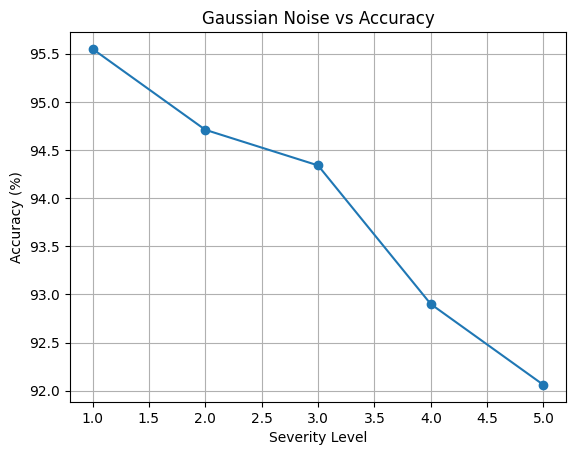

In [70]:
import matplotlib.pyplot as plt

levels = [1, 2, 3, 4, 5]

gaussian_noise = [95.55, 94.71, 94.34, 92.90, 92.06]

plt.figure()
plt.plot(levels, gaussian_noise, marker='o')
plt.title("Gaussian Noise vs Accuracy")
plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

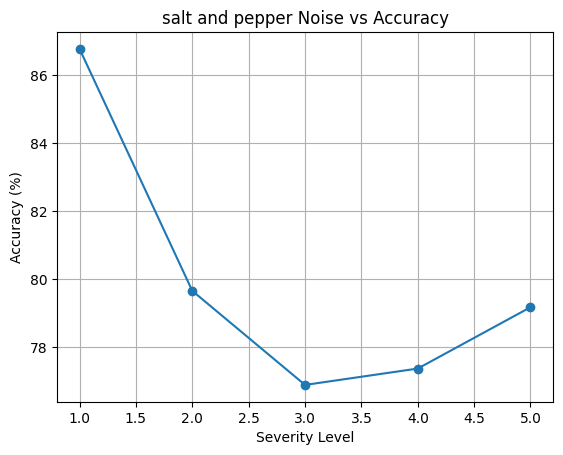

In [71]:
import matplotlib.pyplot as plt

levels = [1, 2, 3, 4, 5]

sp_noise = [86.76, 79.66, 76.90, 77.38, 79.18]

plt.figure()
plt.plot(levels, sp_noise, marker='o')
plt.title("salt and pepper Noise vs Accuracy")
plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

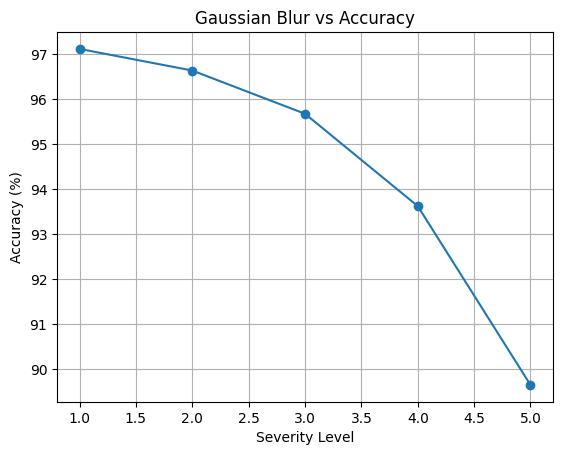

In [72]:
import matplotlib.pyplot as plt

levels = [1, 2, 3, 4, 5]

gaussian_blur = [97.11, 96.63, 95.67, 93.62, 89.65]

plt.figure()
plt.plot(levels, gaussian_blur, marker='o')
plt.title("Gaussian Blur vs Accuracy")
plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

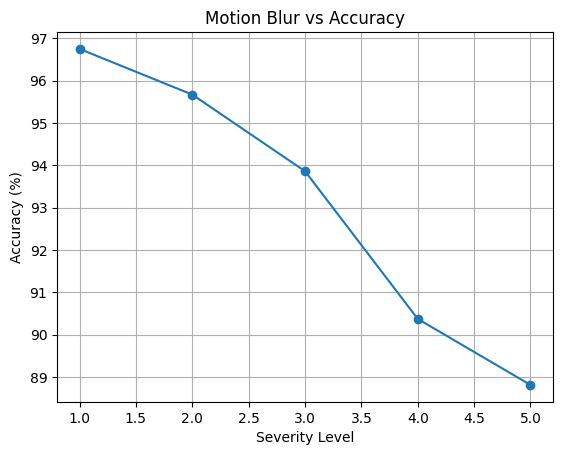

In [73]:
import matplotlib.pyplot as plt

levels = [1, 2, 3, 4, 5]

motion_blur = [96.75, 95.67, 93.86, 90.37, 88.81]

plt.figure()
plt.plot(levels, motion_blur, marker='o')
plt.title("Motion Blur vs Accuracy")
plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

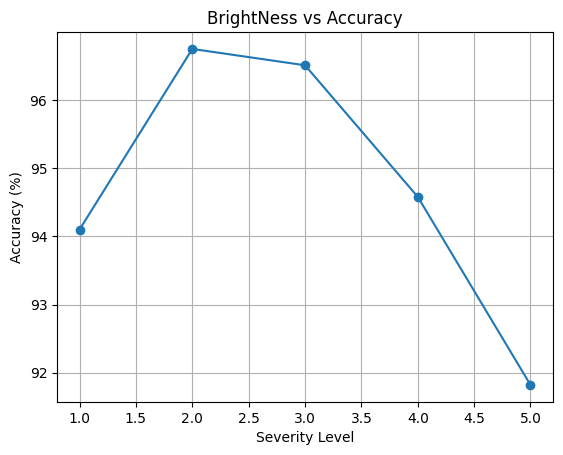

In [74]:
import matplotlib.pyplot as plt

levels = [1, 2, 3, 4, 5]

brightness = [94.10, 96.75, 96.51, 94.58, 91.82]

plt.figure()
plt.plot(levels, brightness, marker='o')
plt.title("BrightNess vs Accuracy")
plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

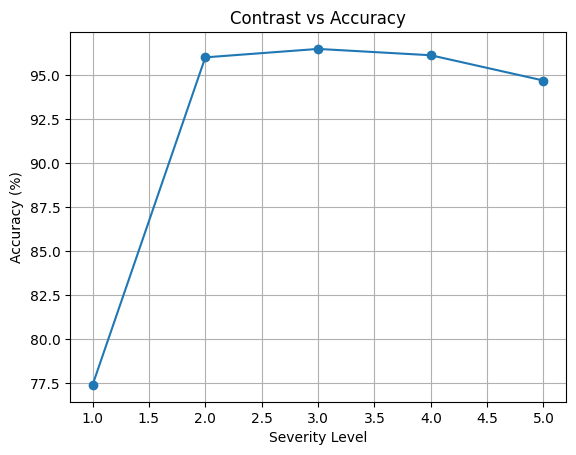

In [75]:
import matplotlib.pyplot as plt

levels = [1, 2, 3, 4, 5]
contrast = [77.38, 96.03, 96.51, 96.15, 94.71]

plt.figure()
plt.plot(levels, contrast, marker='o')
plt.title("Contrast vs Accuracy")
plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

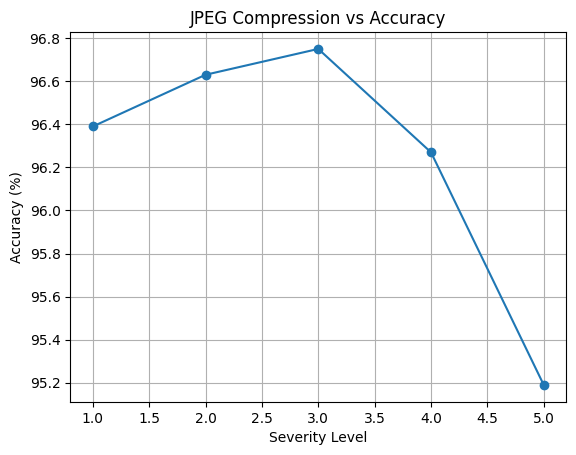

In [76]:
jpeg = [96.39, 96.63, 96.75, 96.27, 95.19]

plt.figure()
plt.plot(levels, jpeg, marker='o')
plt.title("JPEG Compression vs Accuracy")
plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

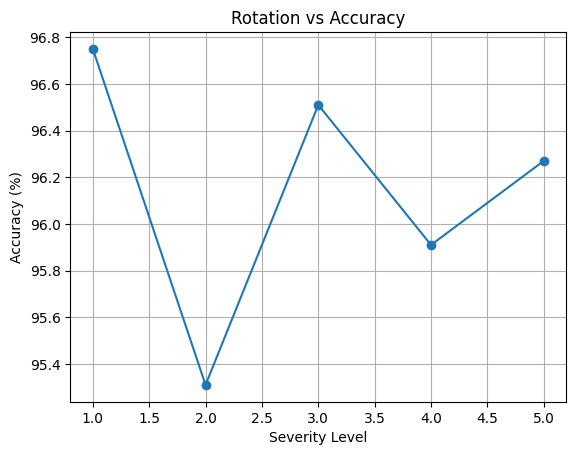

In [77]:
rotation = [96.75, 95.31, 96.51, 95.91, 96.27]

plt.figure()
plt.plot(levels, rotation, marker='o')
plt.title("Rotation vs Accuracy")
plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

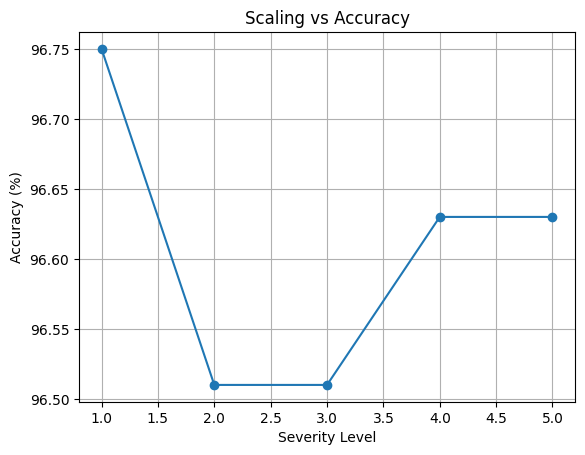

In [78]:
scaling = [96.75, 96.51, 96.51, 96.63, 96.63]

plt.figure()
plt.plot(levels, scaling, marker='o')
plt.title("Scaling vs Accuracy")
plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")
plt.grid()
plt.show()

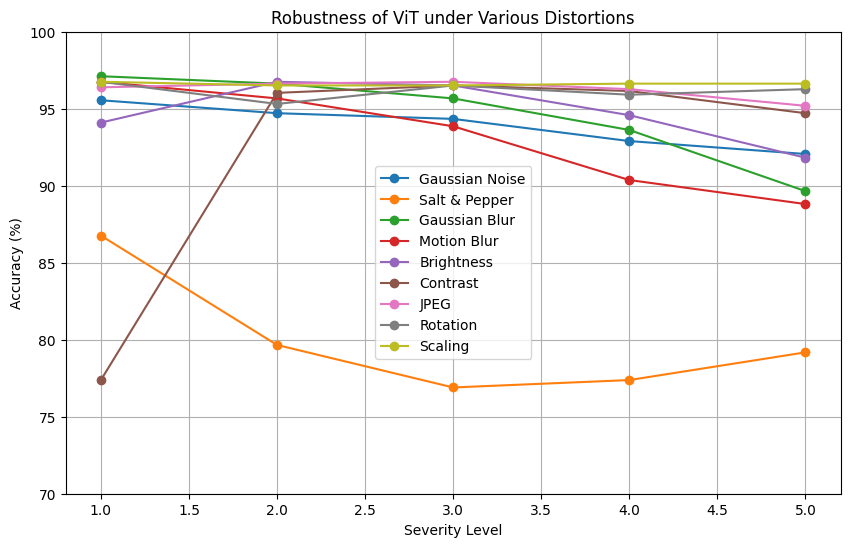

In [80]:
import matplotlib.pyplot as plt

levels = [1, 2, 3, 4, 5]

# =========================
# ALL DISTORTION DATA
# =========================
gaussian_noise = [95.55, 94.71, 94.34, 92.90, 92.06]
sp_noise = [86.76, 79.66, 76.90, 77.38, 79.18]
gaussian_blur = [97.11, 96.63, 95.67, 93.62, 89.65]
motion_blur = [96.75, 95.67, 93.86, 90.37, 88.81]
brightness = [94.10, 96.75, 96.51, 94.58, 91.82]
contrast = [77.38, 96.03, 96.51, 96.15, 94.71]
jpeg = [96.39, 96.63, 96.75, 96.27, 95.19]
rotation = [96.75, 95.31, 96.51, 95.91, 96.27]
scaling = [96.75, 96.51, 96.51, 96.63, 96.63]

# =========================
# PLOT
# =========================
plt.figure(figsize=(10, 6))

plt.plot(levels, gaussian_noise, marker='o', label='Gaussian Noise')
plt.plot(levels, sp_noise, marker='o', label='Salt & Pepper')
plt.plot(levels, gaussian_blur, marker='o', label='Gaussian Blur')
plt.plot(levels, motion_blur, marker='o', label='Motion Blur')
plt.plot(levels, brightness, marker='o', label='Brightness')
plt.plot(levels, contrast, marker='o', label='Contrast')
plt.plot(levels, jpeg, marker='o', label='JPEG')
plt.plot(levels, rotation, marker='o', label='Rotation')
plt.plot(levels, scaling, marker='o', label='Scaling')

plt.title("Robustness of ViT under Various Distortions")
plt.xlabel("Severity Level")
plt.ylabel("Accuracy (%)")

plt.ylim(70, 100)   # ✅ IMPORTANT (for clear comparison)

plt.legend()
plt.grid()

plt.show()

In [82]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

def plot_confusion_matrix_for_path(path, title):
    dataset = datasets.ImageFolder(root=path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    all_preds = []
    all_labels = []

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()

    plt.title(title)
    plt.show()

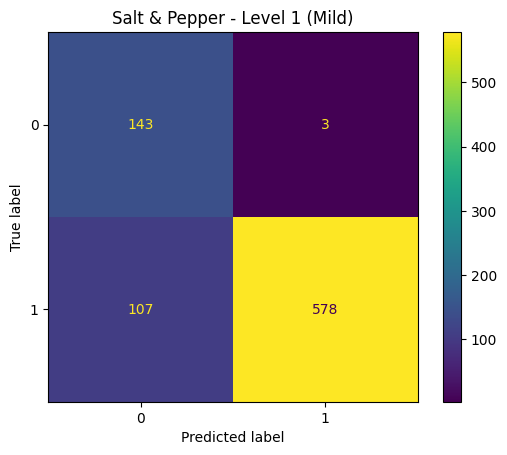

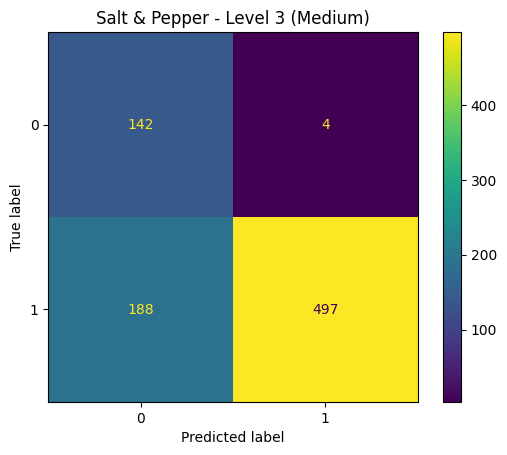

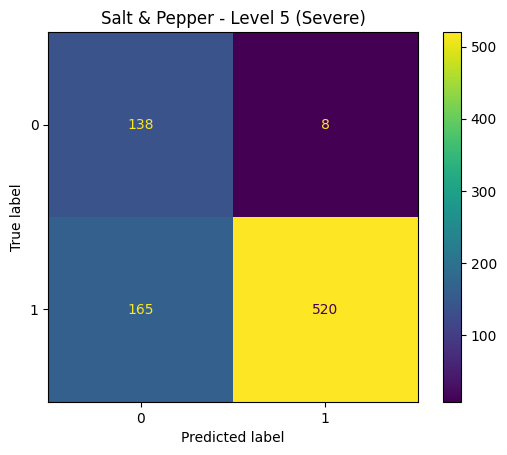

In [83]:
plot_confusion_matrix_for_path(
    "/content/distorted_dataset/sp_noise_lvl1",
    "Salt & Pepper - Level 1 (Mild)"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/sp_noise_lvl3",
    "Salt & Pepper - Level 3 (Medium)"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/sp_noise_lvl5",
    "Salt & Pepper - Level 5 (Severe)"
)

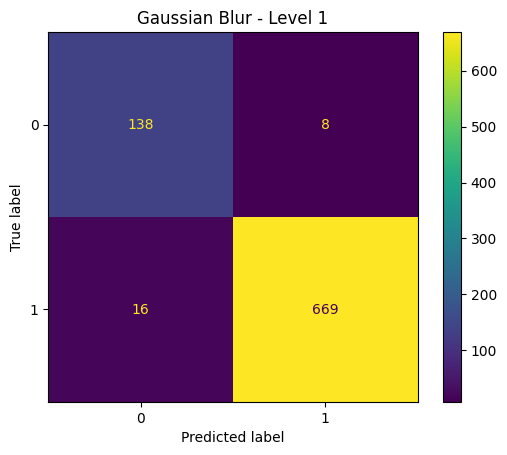

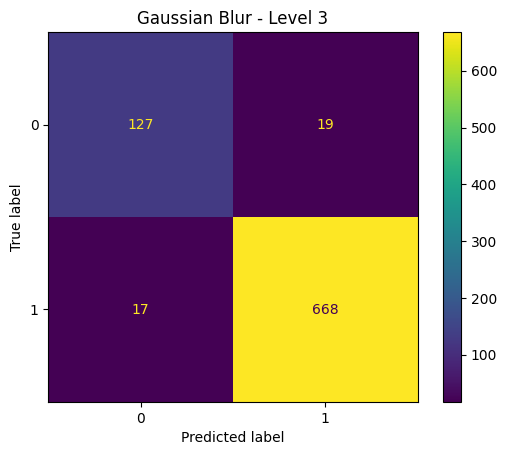

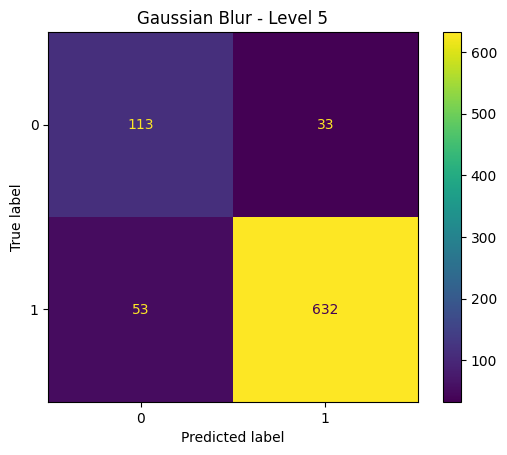

In [84]:
plot_confusion_matrix_for_path(
    "/content/distorted_dataset/blur_lvl1",
    "Gaussian Blur - Level 1"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/blur_lvl3",
    "Gaussian Blur - Level 3"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/blur_lvl5",
    "Gaussian Blur - Level 5"
)

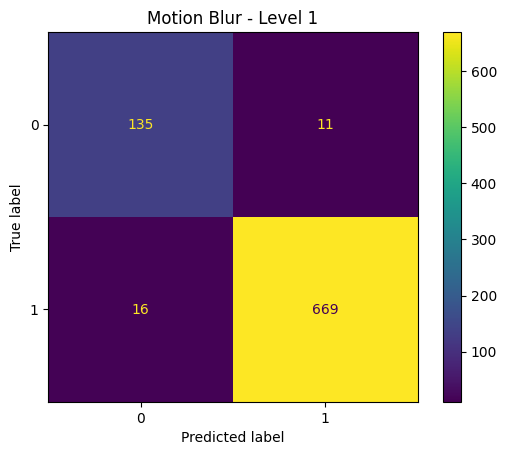

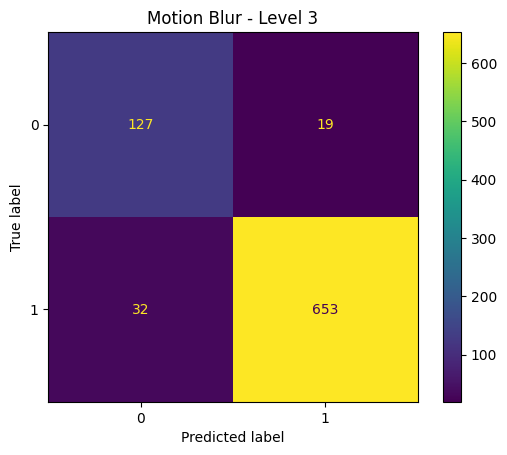

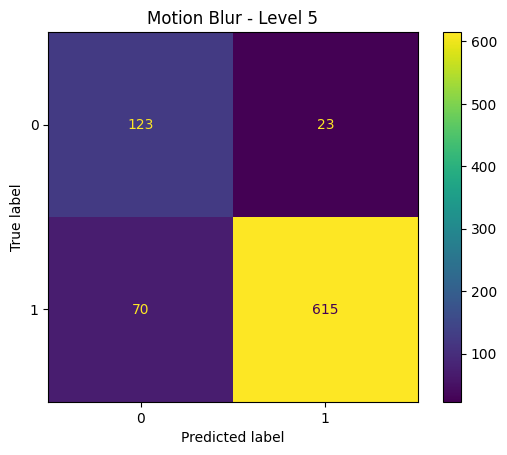

In [85]:
plot_confusion_matrix_for_path(
    "/content/distorted_dataset/motion_blur_lvl1",
    "Motion Blur - Level 1"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/motion_blur_lvl3",
    "Motion Blur - Level 3"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/motion_blur_lvl5",
    "Motion Blur - Level 5"
)

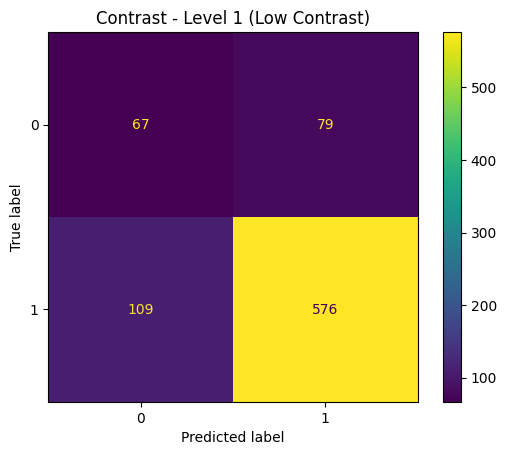

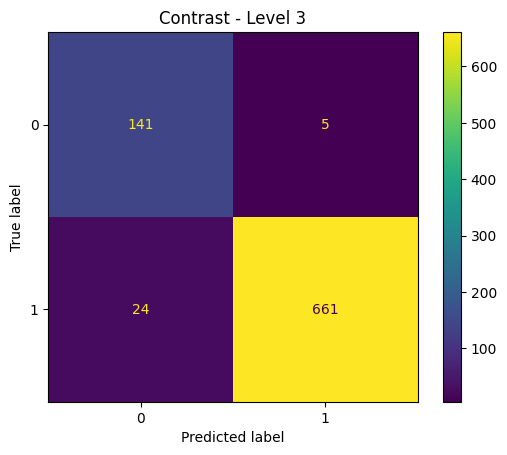

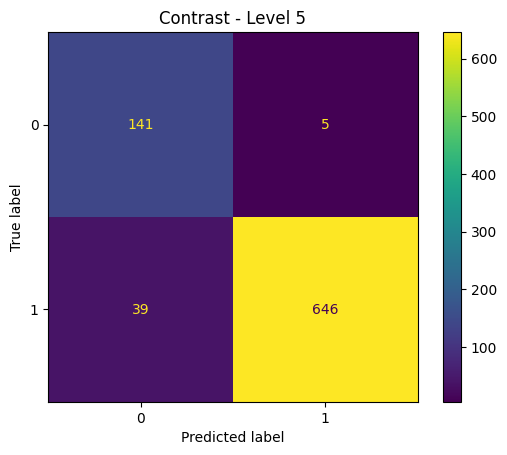

In [86]:
plot_confusion_matrix_for_path(
    "/content/distorted_dataset/contrast_lvl1",
    "Contrast - Level 1 (Low Contrast)"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/contrast_lvl3",
    "Contrast - Level 3"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/contrast_lvl5",
    "Contrast - Level 5"
)

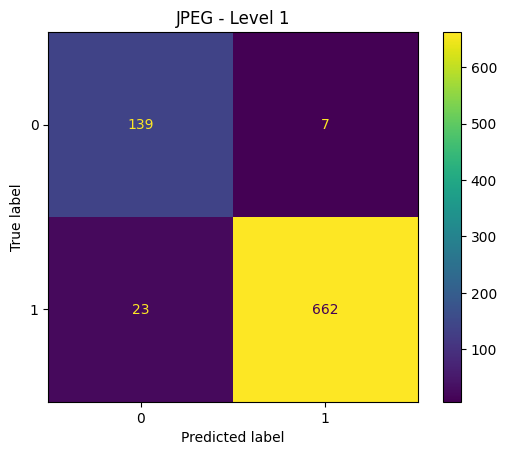

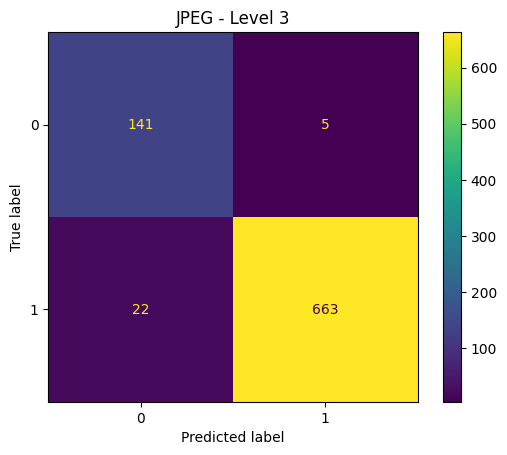

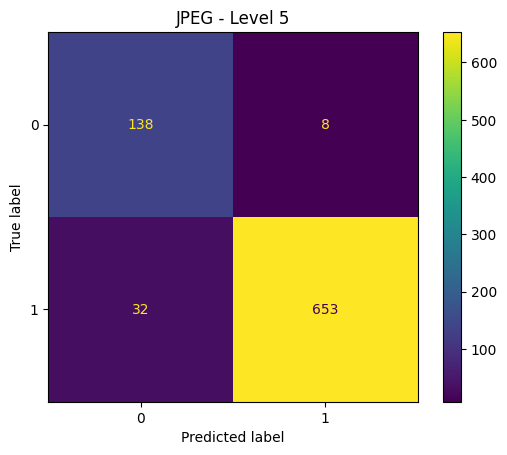

In [87]:
plot_confusion_matrix_for_path(
    "/content/distorted_dataset/jpeg_lvl1",
    "JPEG - Level 1"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/jpeg_lvl3",
    "JPEG - Level 3"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/jpeg_lvl5",
    "JPEG - Level 5"
)

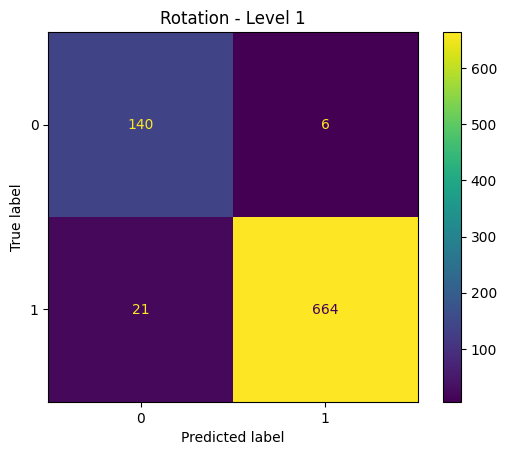

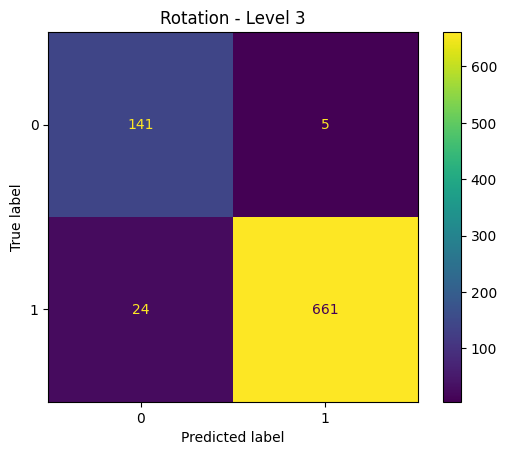

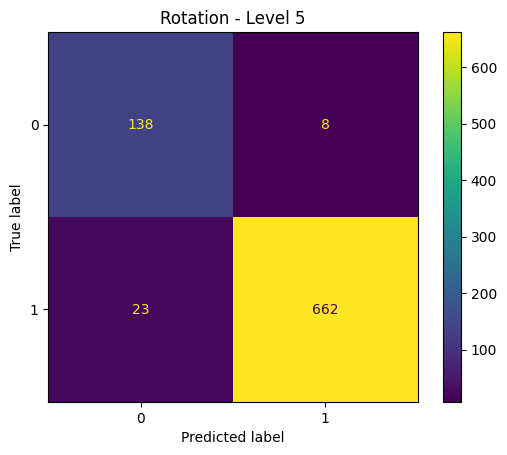

In [88]:
plot_confusion_matrix_for_path(
    "/content/distorted_dataset/rotation_lvl1",
    "Rotation - Level 1"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/rotation_lvl3",
    "Rotation - Level 3"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/rotation_lvl5",
    "Rotation - Level 5"
)

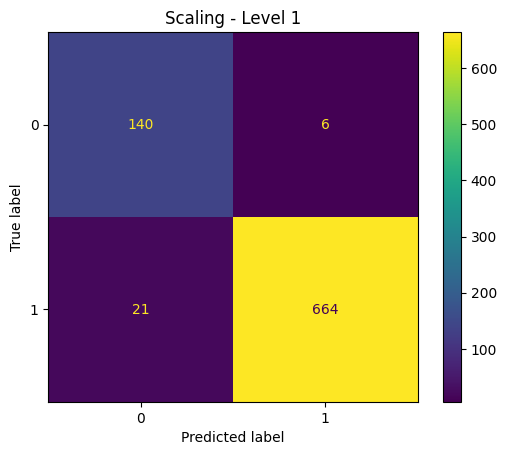

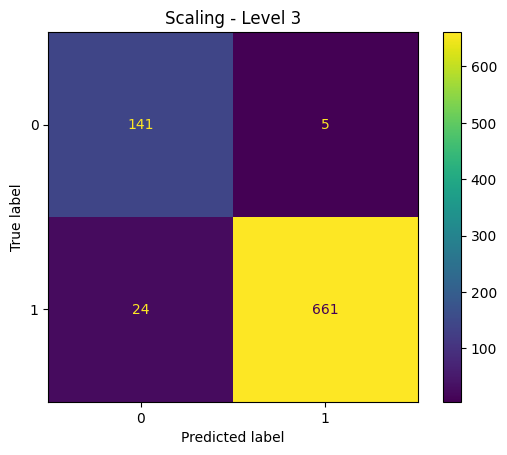

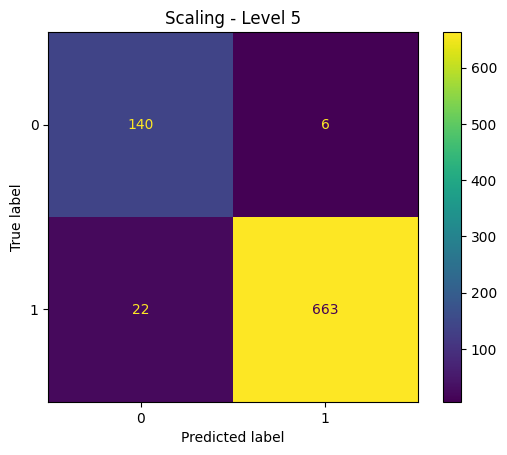

In [89]:
plot_confusion_matrix_for_path(
    "/content/distorted_dataset/scaling_lvl1",
    "Scaling - Level 1"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/scaling_lvl3",
    "Scaling - Level 3"
)

plot_confusion_matrix_for_path(
    "/content/distorted_dataset/scaling_lvl5",
    "Scaling - Level 5"
)

In [9]:
import os

print(os.listdir("dataset"))

['Common Chickweed', 'Cleavers', 'Fat Hen', 'Charlock', 'Scentless Mayweed', 'Loose Silky-bent', 'Common wheat', 'Maize', 'ShepherdтАЩs Purse', 'nonsegmentedv2', 'Black-grass', 'Small-flowered Cranesbill', 'Sugar beet']
